## Chapter 4

# Theory

1. Vad kännetecknar klassificeringsproblem? Ge några exempel på tillämp-
ningsområden.

Predicting a non-sequential dependent variable, or categorical data.  Can be used for example to make customer predictions such as for example which class of items they tend to buy, or any other categorical variable, be it ordinal or nominal.

2. Förklara hur OvR- och OvO-algoritmerna fungerar.

The different classification algorithms classify data somewhat differently, both to make binary predictions. With OvR (One-vs-Rest), training one model to predict which of the binary choices a datapoint belongs to. Whereas OvO (one-vs-one), instead trains a separate model for each pair of classes, then evaluates across the pairs which class was predicted most frequently.

3. Förklara följande utvärderingsmått:

a) Confusion matrix

A confusion matrix is a visualization matrix depicting the true value, crossed with the predicted value. Meaning it is a way to show how accurately the model is able to predict the values, according to their classes. Which can be a usefull visualization if a certain kind of error, or prediction is more important.

b) Accuracy

The accuracy is the number of datapoints which are classified correctly.

c) Precision

Precision is the percentage of positive predictions which were predicted correctly. (true positives/(true positives+false positives))

d) Recall

Precision is percentage of the positives from the ground truth which were predicted correctly. (True positives/(true positives + false negatives))

e) 𝐹 1-score

The F1-Score is a harmonic mean of Precision and Recall, meaning a high F1-score necessitates both a high precision and recall, and is a way of measuring how good the model is at making a prediction, which is good at showing if the model is skewed

f) ROC-kurvan

Standing for Reciever Operating Characteristic Curve. The ROC curve visualizes the correlation between the true prositive rate (recall) and the false positive rate. It can also be defined as the correlation between sensitivity (recall) and 1-specificity (false positive/(false positive + True Negative)) (or in plain words how many negatives it is missing in proportion). Meaning that in plain words, the ROC-curve is a graph of how many of the true positives the model is able to catch, vs how many of the true negatives it is missing. The curve depicting moving along various thresholds.

4. Vad är precision-recall tradeoff för något?

It functions similar to the tradeoff between sensitivity and specificity. That as you increase the sensitivity to catch more of the true positives, you will also be falsely predicting more of the true negatives as positives. In this case describing the behaviour that a model making fewer false negatives, will be making more false positives, and vice versa.

5. Några vanligt förekommande modeller för klassificeringsproblem är enligt
nedan. Förklara översiktligt hur respektive modell fungerar. 

a) Logistisk regression

The Logistic regression model is a binary classifier for classification problems, which predicts the probability that a datapoint belongs to a class. If it reaches a 50% predicted probability, the datapoint is classified as belonging to said class. The logistic regression model shares a similar formula to linear regression, treating the outdata as a linear combination of indata in the same fashion. (With some modification to fit the requirement of classifying the outdata).

b) Support vector machines 

SVMs creates a path, in regression problems it captures as much of the datapoints as possible, then draws a line through the center of said path. For classification problems, the SVM instead creates a path which tries to separate the data between the classes which is as broad as possible. Using soft margin classification, we can then specify how many violations of this path we permit (margin violations).

c) Beslutsträd

Decision trees can be applied to both regression problems and classification problems, it can carry out multioutput multiclass classifications, as seen when we used it for regression problems. We can also use it to calculate probabilities in the same fashion as we have been doing with linear regression and SVMs.

d) Ensemble learning 

Ensamble Learning works in a similar way to how it is used in regression problems, multiple models are trained, rather than a singular one. But were as in regression problems the result averaged, for classification problems, this is determined through a voting classifier. Either through hard voting, where prediction determined by the majority of the models determines the final prediction, or soft voting, where the probability of the prediction of the models is used to determine the final prediction.

e) Random forest 

Just as when applied to regression problems, random forest remains an ensemble of decision trees.

f) Extra trees 

Exra Trees is short for Extremely Randomized Trees, it is a model of random trees with a random threshold value at each split.
It has the tradeoff of a lower variance, but a higher bias.

6. Vad innebär det att vi kan kolla på feature importance med hjälp av träd-
modeller såsom beslutsträd eller random forest?

Decision trees can show the importance of a feature when determining how to split the datapoints. Meaning that the feature was more usefull for determining their sorting.

7. Stina säger till Kalle på lunchsamtalet “jag vill ha högsta möjliga precision
för vår klassificieringsmodell”. Kalle funderar ett tag och säger “men vad
händer då med recall”? Vad hade du svarat? I vilka fall kan man tänka sig
vilja ha en så hög precision som möjligt? I vilka fall kan det vara dåligt?
Om vi tänker oss rättsväsendet där en slutgiltig dom kan leda till fängelse,
vad kan vi då säga om precision-recall tradeoff ?

Recall would get worse. This can be useful in cases where we absolutely want to prevent false negatives, or in other words when only the only positive predictions are true positives. This is something which would align with the needs of a criminal court judgement as was given as an example, as, if this was to be used for an absolute judgement of guilty, getting a false positive would be more important to avoid.

8. Förklara hur man kan tolka figur 4.8 på sidan 175.

The grid depicts the prediction of a logistic regression model based on two independent variables.
The color of the nodes depict the true group of the datapoints, while the color of the background displays the certainty of the prediction the model makes that a node is 'positive', displaying how the model makes its predictions.

9. På sidan 209 står det “på träningsdatan använder vi .fit_transform(),
på valideringsdatan och testdatan använder vi endast .transform().” För-
klara logiken bakom detta.

fit_transform(), is a combined fit and transformer, which fits the standardscaler to the data, such that it can carry out an appropriate tranformation. As the scaler is already fit to the data, we then only need to carry out a transformaton of the validation and test data.

# Code

10. Gå igenom samtliga kodexempel i kapitlet och skriv gärna av koden ma-
nuellt. Det är även bra att experimentera genom att ändra vissa delar av
koden och läsa dokumentationen.

In [34]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn import tree
from sklearn.pipeline import Pipeline

11. Förklara vad nedanstående kod gör och tolka resultatet från koden.

In [2]:
y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]
target_names = ['class 0', 'class 1', 'class 2']
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



The code uses sklearns built in confusion_report function to get relevant data about our predition as compared to our ground truth, we can here see metrics such as precision, recall, f1-score, for each of out classes, with the number of entries inside our ground truth. We can also see metrics such as accuracy, an average of our metrics for our predictions, as well as a weighted average acounting for the number of entries in our classes.

12. Läs dokumentationen och visualisera ett beslutsträd: https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

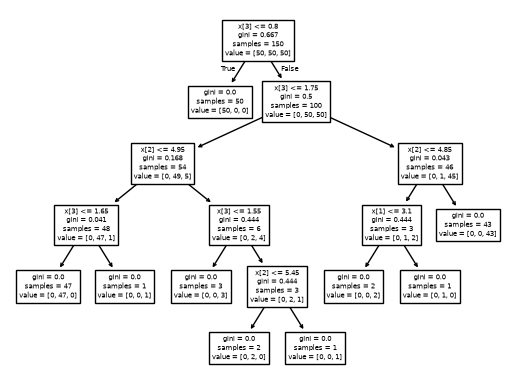

In [ ]:
from sklearn.datasets import load_iris

clf = DecisionTreeClassifier(random_state=0)
iris = load_iris()

clf = clf.fit(iris.data, iris.target)
tree.plot_tree(clf)

13. I föregående kapitel gjordes en EDA på datasetet “hr_employee_data.xlsx”.
Gör nu ett komplett ML-flöde där den beroende variabeln, 𝑦, är left.
Om den variabeln är 1 så betyder det att den anställde har lämnat
företaget och om den är 0 så betyder det att den anställde inte har lämnat
företaget, det vill säga jobbar kvar.

In [11]:
dataset = pd.read_excel("hr_employee_data.xlsx")

dataset.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [12]:
dataset = dataset.drop(columns=['Emp_Id'])
X = dataset.drop(columns=['left'])
y = dataset['left']

X.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,0,sales,low
1,0.80,0.86,5,262,6,0,0,sales,medium
2,0.11,0.88,7,272,4,0,0,sales,medium
3,0.72,0.87,5,223,5,0,0,sales,low
4,0.37,0.52,2,159,3,0,0,sales,low


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

print(X_train.shape)
print(y_train.shape)

(11999, 9)
(11999,)


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

#Encode + transform dataframe
encode_process = ColumnTransformer(
    transformers = [
        ('nominal', OneHotEncoder(), ['Department']),
        ('ordinal', OrdinalEncoder(categories=[
            ['low', 'medium', 'high']
        ]), ['salary'])
    ],
    remainder = 'passthrough'
)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_leaf_nodes=16,
    random_state=20
)

employee_churn_classifier = Pipeline([
    ('encoder', encode_process),
    ('classifier', rf_clf)
])

employee_churn_classifier.fit(X_train, y_train)
rf_clf_pred = employee_churn_classifier.predict(X_test)

accuracy_score(y_test, rf_clf_pred)

0.9716666666666667

14. Nedan ser vi en början till modellering av ett mycket berömt dataset kopplat till blommor. Läs på vad datasetet innebär och genomför ett komplett
ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

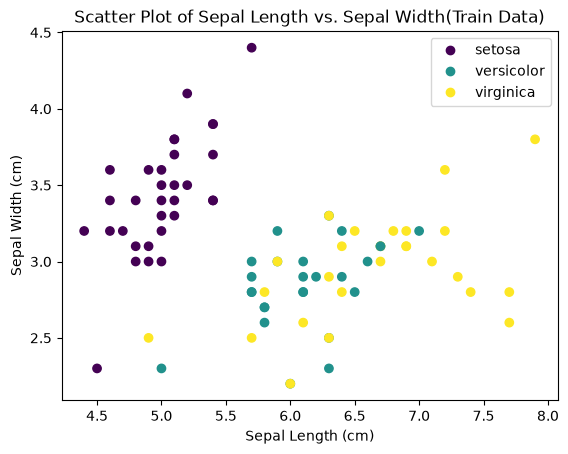

In [ ]:
from sklearn.datasets import load_iris #A dataset containing data about 3 different Iris species
# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()
print(iris.DESCR)
print(iris.target_names)
X, y = load_iris(return_X_y=True, as_frame=True)
# Only choose two variables for the modelling to keep it simple
X = X[['sepal length (cm)', 'sepal width (cm)']]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width(Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [18]:
tree_clf = DecisionTreeClassifier()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

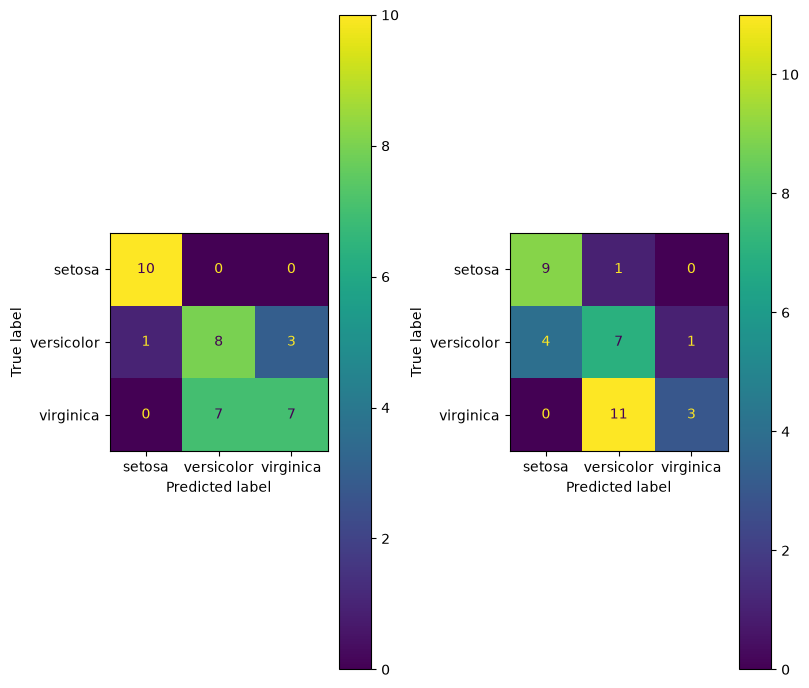

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

target_names_iris = ['setosa', 'versicolor', 'virginica']

cm1 = confusion_matrix(y_val, log_reg_pred)
cm2 = confusion_matrix(y_val, clf_pred)

fig, axs = plt.subplots(1, 2, figsize = (8, 7), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = target_names_iris).plot(ax=axs[0])
ConfusionMatrixDisplay(cm2, display_labels = target_names_iris).plot(ax=axs[1])

In [22]:
print("Logistic Regression:\n")
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))
print("Decision Tree:\n")
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

Logistic Regression:

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36

Decision Tree:

              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



In [23]:
log_reg_final = LogisticRegression().fit(X_train_full, y_train_full)
pred_test = log_reg_final.predict(X_test)

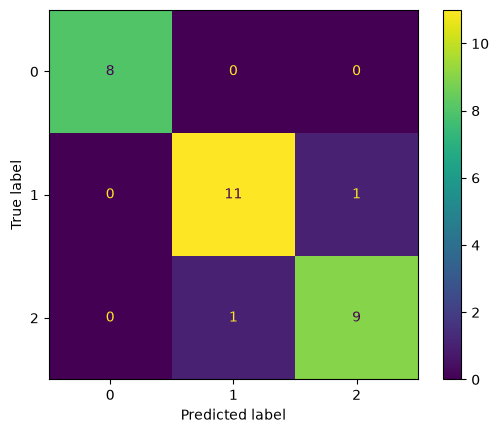

In [24]:
cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test).plot()

In [25]:
print(classification_report(y_test, pred_test, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



15. I avsnitt 4.4.1 “Kodexempel 1 - Klassificering av MNIST” modelleras
MNIST. Skriv kod så att du kan ta egna bilder (via exempelvis mobilen)
på handskrivna siffror och prediktera dessa. Om du känner dig inspirerad
kan du också skapa en Streamlit applikation. Notera, det huvudsakliga
arbetet blir alltså att preprocessa, det vill säga bearbeta bilderna som
tas via mobilen så modellen kan prediktera dem. I verkligheten är det
ofta långt ifrån trivialt att genomföra preprocessing.

In [27]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()

In [28]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist['data'][:10000]
y = mnist['target'][:10000].astype(np.uint8)
X.shape
y.shape

(10000,)

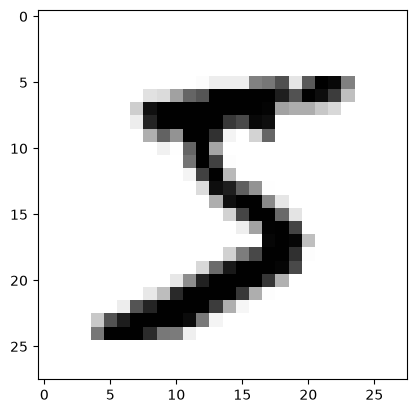

In [29]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)

In [31]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [32]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=2000, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=2000, random_state=40)

In [35]:
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf)
]

voting_clf = VotingClassifier(named_estimators, voting='hard')

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf] 
for model in models:
    model.fit(X_train, y_train)

print("Accuracy for each model") 
model_names = ["Logistic Regression", "Random Forest", "Extra Trees", "Voting Classifier"]

for name, model in zip(model_names, models): 
    score = model.score(X_val, y_val)
    print (f"{name:20s}: {score: .4f}")

Accuracy for each model
Logistic Regression :  0.8845
Random Forest       :  0.9410
Extra Trees         :  0.9455
Voting Classifier   :  0.9420


              precision    recall  f1-score   support

           0       0.96      0.99      0.97       217
           1       0.95      0.97      0.96       207
           2       0.93      0.93      0.93       217
           3       0.95      0.91      0.93       187
           4       0.95      0.94      0.94       191
           5       0.93      0.93      0.93       192
           6       0.93      0.97      0.95       188
           7       0.95      0.95      0.95       214
           8       0.96      0.89      0.92       184
           9       0.94      0.96      0.95       203

    accuracy                           0.95      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.95      0.95      0.95      2000



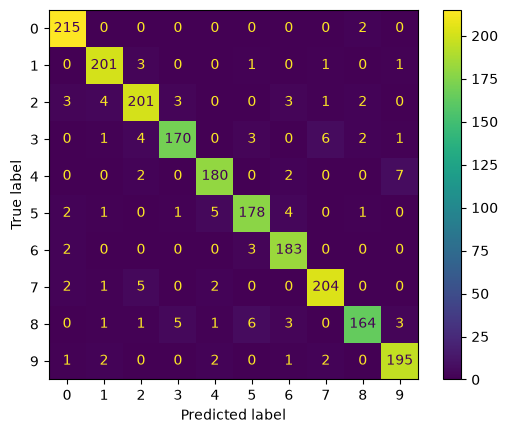

In [36]:
et_pred_val = extra_trees_clf.predict(X_val)

display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       217
           1       0.95      0.97      0.96       207
           2       0.93      0.93      0.93       217
           3       0.95      0.91      0.93       187
           4       0.95      0.94      0.94       191
           5       0.93      0.93      0.93       192
           6       0.93      0.97      0.95       188
           7       0.95      0.95      0.95       214
           8       0.96      0.89      0.92       184
           9       0.94      0.96      0.95       203

    accuracy                           0.95      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.95      0.95      0.95      2000



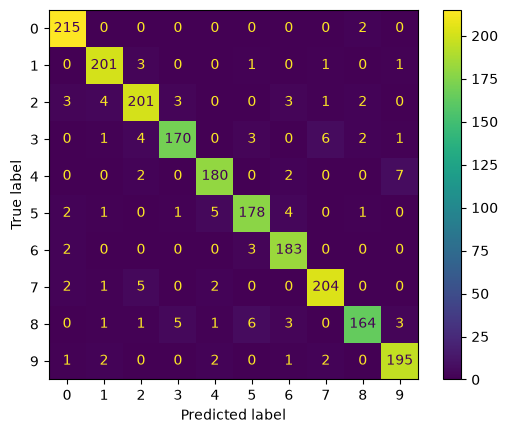

In [37]:
extra_trees_clf.fit(X_train_val, y_train_val)
et_pred_test = extra_trees_clf.predict(X_test)

display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

In [ ]:
extra_trees_clf.fit(X, y)

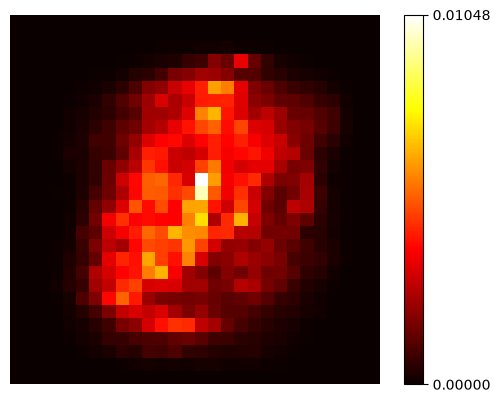

In [40]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.hot, interpolation='nearest')
    plt.axis('off')

plot_digit(extra_trees_clf.feature_importances_)

cbar = plt.colorbar(ticks=[extra_trees_clf.feature_importances_.min(), extra_trees_clf.feature_importances_.max()])

In [38]:
#Save model for Kap415.py
import joblib
joblib.dump(extra_trees_clf, 'kap415model.pk1')
print('kap415model Saved')

kap415model Saved


For further implementation, please refer to kap415.py